# MARICL — Multi-Agent Residual In-Context Learning

A faithful implementation of MARICL (Multi-Agent Residual In-Context Learning)
following the equations in the methods section, using **LangChain** + the **OpenAI API**.

MARICL learns $K$ closed-form *correction agents* on top of a pretrained base model
$f_{\text{ML}}$. Each agent pairs a natural-language explanation $T_k$ with an executable
formula $f_k$. Predictions are formed as

$$\hat{y}_{\text{MARICL}}(\mathbf{x}) = f_{\text{ML}}(\mathbf{x}) + \sum_{k=1}^{K} \alpha_k(\mathbf{x})\,f_k(\mathbf{x})\qquad\text{(regression)}$$

$$P_{\text{MARICL}}(\mathbf{x}) = \beta\, P_{\text{ML}}(\mathbf{x}) + (1-\beta)\sum_{k=1}^{K} \alpha_k(\mathbf{x})\,Q_k(\mathbf{x})\qquad\text{(classification)}$$

The notebook is organised as:

1. **Setup** — install deps, imports, API key.
2. **Sandboxed formula execution** (Appendix A.2).
3. **LLM components**: encoder, decoder, critique, refinement (§ 3.1, § 3.2).
4. **Full MARICL pipeline** (Algorithm 1).
5. **Experiment 1 — synthetic regression**.
6. **Experiment 2 — synthetic classification**.


## 1. Setup

Install LangChain + OpenAI + standard ML deps. If you already have them, skip the next cell.

In [45]:
%pip install -q langchain langchain-openai openai pydantic numpy scikit-learn matplotlib python-dotenv

Note: you may need to restart the kernel to use updated packages.


In [46]:
import os, json, re, ast, math, random, warnings
from dataclasses import dataclass, field
from typing import List, Dict, Tuple, Optional, Callable, Any

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (mean_absolute_error, r2_score,
                             accuracy_score, f1_score, log_loss)

from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import SystemMessage, HumanMessage

warnings.filterwarnings("ignore")
np.random.seed(0); random.seed(0)
print("env ready")

env ready


### API key

The next cell loads **`OPENAI_API_KEY`** from a **`.env`** file next to this notebook (project root), if present. You can also set `OPENAI_API_KEY` or `API_KEY` in the environment before running.

We use **`gpt-5.4-mini`** (override with **`MAICL_MODEL_NAME`**). For GPT-5 family models, **`OPENAI_REASONING_EFFORT`** defaults to `low` (set to `none` to disable).

In [47]:
from pathlib import Path

try:
    from dotenv import load_dotenv
    load_dotenv(Path.cwd().resolve() / ".env")
except ImportError:
    pass

# Normalize key from .env or env (API_KEY alias matches maricl_synthetic_demo.ipynb)
_key = (os.environ.get("OPENAI_API_KEY") or os.environ.get("API_KEY", "")).strip()
if _key:
    os.environ["OPENAI_API_KEY"] = _key

assert os.environ.get("OPENAI_API_KEY"), (
    "Set OPENAI_API_KEY in .env or the environment (API_KEY is also accepted)."
)

LLM_MODEL = os.environ.get("MAICL_MODEL_NAME", "gpt-5.4-mini")
_re = (os.environ.get("OPENAI_REASONING_EFFORT", "medium") or "").strip().lower()
REASONING_EFFORT = None if _re in ("", "none", "off") else _re

_llm_kw = dict(model=LLM_MODEL, temperature=0.4)
_llm_creative_kw = dict(model=LLM_MODEL, temperature=0.7)
if REASONING_EFFORT:
    _llm_kw["reasoning_effort"] = REASONING_EFFORT
    _llm_creative_kw["reasoning_effort"] = REASONING_EFFORT

llm = ChatOpenAI(**_llm_kw)
llm_creative = ChatOpenAI(**_llm_creative_kw)  # used for diverse encoder prompts
print(
    f"LLM ready: {LLM_MODEL}"
    + (f", reasoning_effort={REASONING_EFFORT}" if REASONING_EFFORT else "")
)

LLM ready: gpt-5.4-mini, reasoning_effort=medium


## 2. Sandboxed formula execution  (Appendix A.2)

The decoder returns a single-line Python expression in $f_k$. We:

* **Parse it with `ast`** and reject any disallowed AST nodes (imports, calls to
  arbitrary names, attribute access starting with `_`, loops, lambdas, etc.).
* **Eval it** inside a namespace containing only whitelisted operators
  (`clip`, `exp`, `log1p`, `maximum`, `minimum`, `abs`, `sqrt`, `sigmoid`,
  `where`, `tanh`, `sign`) plus the feature arrays.
* **Validate the output**: NaN/Inf → reject; out-of-range → clip with a warning.

This is the only thing that runs at inference time — zero LLM cost.

In [48]:
def _safe_exp(x):
    return np.exp(np.clip(np.asarray(x, dtype=float), -50, 50))

def _safe_log(x):
    return np.log(np.maximum(np.asarray(x, dtype=float), 1e-10))

def _safe_sqrt(x):
    return np.sqrt(np.maximum(np.asarray(x, dtype=float), 0.0))

def _sigmoid(x):
    return 1.0 / (1.0 + _safe_exp(-np.asarray(x, dtype=float)))

ALLOWED_FUNCS: Dict[str, Callable] = {
    "clip":    np.clip,
    "exp":     _safe_exp,
    "log":     _safe_log,
    "log1p":   np.log1p,
    "maximum": np.maximum,
    "minimum": np.minimum,
    "abs":     np.abs,
    "sqrt":    _safe_sqrt,
    "sigmoid": _sigmoid,
    "tanh":    np.tanh,
    "where":   np.where,
    "sign":    np.sign,
    # numeric constants
    "pi":      np.pi,
    "e":       np.e,
}

# AST nodes we allow; everything else is rejected.
_ALLOWED_NODES = (
    ast.Expression, ast.Load, ast.Name, ast.Constant, ast.Num,
    ast.BinOp, ast.UnaryOp, ast.BoolOp, ast.Compare, ast.IfExp,
    ast.Call, ast.Tuple, ast.List,
    # operators
    ast.Add, ast.Sub, ast.Mult, ast.Div, ast.Pow, ast.Mod,
    ast.USub, ast.UAdd,
    ast.And, ast.Or, ast.Not,
    ast.Eq, ast.NotEq, ast.Lt, ast.LtE, ast.Gt, ast.GtE,
)

def validate_formula(expr: str, allowed_features: List[str]) -> Tuple[bool, str]:
    """Return (ok, reason)."""
    if not expr or len(expr) > 2000:
        return False, "empty / too long"
    try:
        tree = ast.parse(expr, mode="eval")
    except SyntaxError as e:
        return False, f"syntax: {e}"

    allowed_names = set(ALLOWED_FUNCS.keys()) | set(allowed_features)
    for node in ast.walk(tree):
        if not isinstance(node, _ALLOWED_NODES):
            return False, f"disallowed node: {type(node).__name__}"
        if isinstance(node, ast.Call):
            if not isinstance(node.func, ast.Name):
                return False, "call must target a bare name"
            if node.func.id not in ALLOWED_FUNCS:
                return False, f"call to disallowed func: {node.func.id}"
        if isinstance(node, ast.Name):
            if node.id.startswith("_"):
                return False, f"private name: {node.id}"
            if node.id not in allowed_names:
                return False, f"unknown name: {node.id}"
    return True, "ok"


def execute_formula(
    expr: str,
    X: np.ndarray,
    feature_names: List[str],
    out_dim: int = 1,
    output_range: Optional[Tuple[float, float]] = None,
) -> np.ndarray:
    """Evaluate `expr` row-wise (or vectorised) on X.

    Features in X[:, i] are bound to the name `feature_names[i]` as a 1-D
    numpy array, so the formula can be fully vectorised.
    Returns an array of shape (N,) for out_dim==1 or (N, out_dim).
    Raises ValueError on validation / runtime failure.
    """
    ok, reason = validate_formula(expr, feature_names)
    if not ok:
        raise ValueError(f"validation failed: {reason}")

    X = np.asarray(X, dtype=float)
    if X.ndim == 1:
        X = X.reshape(1, -1)
    feat_dict = {name: X[:, i] for i, name in enumerate(feature_names)}

    namespace = {**ALLOWED_FUNCS, **feat_dict}
    try:
        out = eval(expr, {"__builtins__": {}}, namespace)
    except Exception as e:
        raise ValueError(f"runtime error: {e}")

    out = np.asarray(out, dtype=float)
    # broadcast scalar -> per-row
    if out.ndim == 0:
        out = np.full(X.shape[0], float(out))

    if not np.all(np.isfinite(out)):
        # post-execution validation (Appendix A.2)
        raise ValueError("non-finite output")

    if output_range is not None:
        lo, hi = output_range
        out = np.clip(out, lo, hi)

    return out


In [49]:
# quick sanity check on the sandbox
ok, why = validate_formula("0.5 * x1 + sigmoid(x1 * x2) - clip(x3, -1, 1)", ["x1", "x2", "x3"])
assert ok, why
bad_cases = [
    "__import__('os').system('ls')",
    "open('foo').read()",
    "[i for i in range(10)]",
    "lambda x: x",
    "x1 ** y_unknown",
]
for b in bad_cases:
    ok, why = validate_formula(b, ["x1"])
    print(f"  blocked={str(not ok):5s}  reason={why!s:60s}  expr={b!r}")


  blocked=True   reason=call must target a bare name                                  expr="__import__('os').system('ls')"
  blocked=True   reason=call must target a bare name                                  expr="open('foo').read()"
  blocked=True   reason=disallowed node: ListComp                                     expr='[i for i in range(10)]'
  blocked=True   reason=disallowed node: Lambda                                       expr='lambda x: x'
  blocked=True   reason=unknown name: y_unknown                                       expr='x1 ** y_unknown'


## 3. LLM components — encoder / decoder / critique / refinement

We define structured outputs with **Pydantic**, which LangChain binds via
`with_structured_output`. This is more reliable than free-form parsing.

* **Encoder** $\mathcal{P}_{\text{encoder}}^{(k)}$  — produces a structured hypothesis $z_k$
  about *what the base model misses* (Eq. 6). We use $K$ encoder variants
  ("error patterns" and "sample patterns") per the paper.
* **Decoder** $\mathcal{P}_{\text{decoder}}$ — turns $z_k$ into $(T_k, f_k)$ where $f_k$ is
  a sandbox-executable expression.
* **Critique** $\mathcal{P}_{\text{critique}}$ — given current loss and worst failures
  produces a textual gradient $g_k^{(t)}$ (Eq. 12).
* **Refinement** — generates $(T_k^{(t+1)}, f_k^{(t+1)})$ from the accumulated state.


In [50]:
class Hypothesis(BaseModel):
    """Structured hypothesis z_k produced by the encoder."""
    hypothesised_pattern: str = Field(
        description="One-sentence statement of the pattern the base model misses.")
    implicated_features: List[str] = Field(
        description="Feature names involved in the pattern. Must match provided names.")
    functional_form_guess: str = Field(
        description="A guess at the functional form (e.g. 'saturating x1*x2/(1+x1*x2)').")
    rationale: str = Field(
        description="2-3 sentence explanation grounded in the residual evidence.")


class Correction(BaseModel):
    """The (T_k, f_k) pair produced by the decoder."""
    T_k: str = Field(
        description="Natural-language explanation (2-3 sentences) of the correction.")
    f_k: str = Field(
        description=(
            "Single Python expression for the correction. Use ONLY: arithmetic + "
            "clip, exp, log, log1p, maximum, minimum, abs, sqrt, sigmoid, tanh, "
            "where, sign. No imports, no loops, no lambdas. Reference features "
            "by their exact names. For classification, return a list of length C: "
            "e.g. '[s_0, s_1, s_2]'."
        )
    )


class Critique(BaseModel):
    """Textual gradient g_k^(t)."""
    diagnosis: str = Field(
        description="Why does the current correction fail on these examples?")
    structural_or_coefficient: str = Field(
        description="'structural' if the functional form is wrong, 'coefficient' if scale.")
    suggested_change: str = Field(
        description="Concrete refinement that addresses the dominant failure mode.")


In [51]:
# ---- Encoder ----

ENCODER_PROMPTS = {
    "error_patterns": (
        "You are analysing the systematic prediction errors of a base ML model "
        "to discover what it misses.\n\n"
        "Focus on ERROR PATTERNS: which feature combinations drive large residuals, "
        "and what nonlinearities the base model fails to capture. Distinguish "
        "interactions, thresholds, saturations, and inverse-U shapes."
    ),
    "sample_patterns": (
        "You are analysing high-residual training examples to learn the TRUE "
        "underlying input->target relationship that the base model misses.\n\n"
        "Focus on SAMPLE PATTERNS: what direct mappings between feature values "
        "and target values are visible in these examples? What rules would predict "
        "well from the sample patterns alone?"
    ),
    "class_boundary": (
        "You are analysing misclassified training examples to discover which feature "
        "combinations determine the true class boundaries that the base classifier misses.\n\n"
        "Focus on CLASS BOUNDARY PATTERNS: for each pair of confused classes, what "
        "feature interaction, product, threshold, or nonlinear combination separates them? "
        "Look for signed interactions (e.g. x1*x2 positive -> class A, negative -> class B), "
        "quadratic terms (x**2), or threshold effects that a linear model cannot capture. "
        "Express your hypothesis as a per-class score correction: positive delta for the "
        "correct class, negative for the confused class."
    ),
}

def format_high_res_table(X: np.ndarray, y: np.ndarray,
                         base_pred: np.ndarray, r: np.ndarray,
                         feature_names: List[str], max_rows: int = 15) -> str:
    """Compact text table of high-residual examples for the LLM.
    Handles both regression (base_pred 1-D) and classification (base_pred 2-D probs).
    """
    idx = np.argsort(-np.abs(r))[:max_rows]
    is_class = (np.asarray(base_pred).ndim == 2)
    base_cols = ["pred_cls", "P(true)"] if is_class else ["base_pred"]
    header = "  ".join(["idx"] + [f"{n:>8s}" for n in feature_names]
                       + [f"{c:>10s}" for c in ["target"] + base_cols + ["residual"]])
    lines = [header]
    for i in idx:
        row = [f"{i:3d}"] + [f"{X[i,j]:+8.3f}" for j in range(X.shape[1])]
        if is_class:
            bp = np.asarray(base_pred[i])
            y_i = int(y[i])
            row += [f"{y_i:>10d}",
                    f"{int(bp.argmax()):>10d}",
                    f"{bp[y_i]:>10.3f}",
                    f"{float(r[i]):+10.3f}"]
        else:
            row += [f"{float(y[i]):+10.3f}",
                    f"{float(base_pred[i]):+10.3f}",
                    f"{float(r[i]):+10.3f}"]
        lines.append("  ".join(row))
    return "\n".join(lines)


def build_aug_context(X_hr: np.ndarray, y_hr: np.ndarray,
                      base_pred_hr: np.ndarray, r_hr: np.ndarray,
                      feature_names: List[str], feature_descs: List[str],
                      domain_context: str, task: str,
                      class_names: Optional[List[str]] = None) -> str:
    """Eq. 5: augmented context = high-residual table + feature descs + domain."""
    feat_block = "\n".join(f"  - {n}: {d}" for n, d in zip(feature_names, feature_descs))
    task_block = f"TASK: {task}"
    if class_names is not None:
        task_block += f"   CLASSES: {class_names}"
    parts = [
        f"DOMAIN CONTEXT: {domain_context}",
        task_block,
        "FEATURES:",
        feat_block,
        "HIGH-RESIDUAL EXAMPLES (sorted by |residual|):",
        format_high_res_table(X_hr, y_hr, base_pred_hr, r_hr, feature_names),
    ]
    return "\n\n".join(parts)


def encode_hypothesis(aug_context: str, prompt_variant: str,
                      n_classes: Optional[int] = None) -> Hypothesis:
    """Eq. 6: z_k = Encode_LM(C_aug, P_encoder^(k))."""
    sys_msg = (
        "You are an expert ML diagnostician. Given evidence of where a base model "
        "fails, you hypothesise the structural pattern it misses, in a form that "
        "could be expressed as a closed-form correction."
    )
    user_msg = ENCODER_PROMPTS[prompt_variant] + "\n\n" + aug_context
    if n_classes is not None:
        user_msg += (f"\n\nNOTE: this is a {n_classes}-class classification problem. "
                     "The correction will output a vector of per-class score deltas.")
    structured = llm_creative.with_structured_output(Hypothesis)
    return structured.invoke([SystemMessage(content=sys_msg),
                              HumanMessage(content=user_msg)])


In [52]:
# ---- Decoder ----

DECODER_SYSTEM = (
    "You convert a structured hypothesis about a base model's residuals into an "
    "executable correction. Follow these rules strictly:\n"
    "1) f_k MUST be a SINGLE Python expression (no statements, no def, no lambda).\n"
    "2) Allowed names: feature names provided + functions {clip, exp, log, log1p, "
    "   maximum, minimum, abs, sqrt, sigmoid, tanh, where, sign} + constants {pi, e}.\n"
    "3) Use numerical stability: clip outputs to a sensible range, add small "
    "   constants to denominators, prefer log1p over log near zero, bound exp args.\n"
    "4) For REGRESSION, f_k returns a scalar correction added to the base prediction.\n"
    "   Example (features x1, x2, x3): '0.5 * x1 * x2 + 0.3 * x3**2'\n"
    "5) For CLASSIFICATION with C classes, f_k returns a Python list literal of C "
    "   arithmetic expressions — one per class — written directly over the feature names.\n"
    "   Example (3 classes, features x1 x2 x3 where class is driven by x1*x2):\n"
    "     '[-(x1*x2 + 0.3*x3**2), -0.5*abs(x1*x2), x1*x2 + 0.3*x3**2]'\n"
    "   Positive delta boosts that class; negative suppresses it.\n"
    "   NEVER use undefined variable names (like 'delta_0'). Write actual arithmetic "
    "   over the provided feature names only.\n"
    "6) Keep coefficients moderate (|c| < 10) unless the residual evidence demands more."
)

def decode_correction(hypothesis: Hypothesis, feature_names: List[str],
                      task: str, n_classes: Optional[int] = None,
                      output_range: Optional[Tuple[float, float]] = None,
                      prior_state: str = "") -> Correction:
    """Eq. 9 / Eq. 14: (T_k, f_k) = Decode_LM(z_k or S_k^(t))."""
    user_msg = (
        f"TASK: {task}\n"
        f"FEATURES: {feature_names}\n"
    )
    if n_classes is not None:
        user_msg += f"NUM_CLASSES: {n_classes}\n"
    if output_range is not None:
        user_msg += f"OUTPUT_RANGE (regression correction will be clipped to this): {output_range}\n"

    user_msg += (
        f"\nHYPOTHESIS:\n"
        f"  pattern:   {hypothesis.hypothesised_pattern}\n"
        f"  features:  {hypothesis.implicated_features}\n"
        f"  form:      {hypothesis.functional_form_guess}\n"
        f"  rationale: {hypothesis.rationale}\n"
    )
    if prior_state:
        user_msg += "\nPRIOR ITERATIONS:\n" + prior_state

    user_msg += (
        "\nProduce T_k (2-3 sentences) and f_k (single Python expression). "
        "Reference features by exact name. Reply via the structured schema."
    )

    structured = llm.with_structured_output(Correction)
    return structured.invoke([SystemMessage(content=DECODER_SYSTEM),
                              HumanMessage(content=user_msg)])


In [53]:
# ---- Critique ----

CRITIQUE_SYSTEM = (
    "You diagnose why a candidate correction fails on the hardest remaining examples.\n"
    "For REGRESSION: 'target' and 'pred' are numeric values; 'error' = pred - target.\n"
    "For CLASSIFICATION: 'target' is the TRUE class label (integer 0/1/2/...); "
    "'pred' is the base model's max-class confidence (not the predicted class); "
    "'error' = 1 - P(true class) — higher means the model is more wrong. "
    "Focus on which feature values correspond to systematic misclassification of "
    "specific classes.\n"
    "Distinguish structural mismatch (wrong functional form) from "
    "coefficient mismatch (right form, wrong scale). Propose a concrete refinement "
    "to f_k using only the allowed feature names and arithmetic."
)

def critique_correction(hypothesis: Hypothesis,
                        correction: Correction,
                        loss: float,
                        failure_table: str) -> Critique:
    """Eq. 12: g_k^(t) = LM(P_critique | z_k, m_k, L_k, E_k)."""
    user_msg = (
        f"HYPOTHESIS: {hypothesis.hypothesised_pattern}\n"
        f"CURRENT_T_k: {correction.T_k}\n"
        f"CURRENT_f_k: {correction.f_k}\n"
        f"TRAIN_LOSS: {loss:.4f}\n\n"
        f"WORST REMAINING FAILURES (input, target, current_prediction, error):\n"
        f"{failure_table}\n\n"
        f"Diagnose the failure mode and suggest a concrete refinement to f_k."
    )
    structured = llm.with_structured_output(Critique)
    return structured.invoke([SystemMessage(content=CRITIQUE_SYSTEM),
                              HumanMessage(content=user_msg)])


def format_failure_table(X_f: np.ndarray, y_f: np.ndarray,
                         pred_f: np.ndarray, err_f: np.ndarray,
                         feature_names: List[str], max_rows: int = 10) -> str:
    idx = np.argsort(-np.abs(err_f))[:max_rows]
    header = "  ".join([f"{n:>8s}" for n in feature_names]
                       + [f"{c:>10s}" for c in ["target", "pred", "error"]])
    lines = [header]
    for i in idx:
        row = [f"{X_f[i,j]:+8.3f}" for j in range(X_f.shape[1])]
        row += [f"{y_f[i]:+10.3f}", f"{pred_f[i]:+10.3f}", f"{err_f[i]:+10.3f}"]
        lines.append("  ".join(row))
    return "\n".join(lines)


## 4. MARICL pipeline (Algorithm 1)

Putting it all together: residual computation → high-residual subset → augmented
context → batched encoder → decoder → textual-gradient refinement → best-iterate
selection → global score + per-query confidence → aggregation.


In [54]:
@dataclass
class CorrectionState:
    """Tracks one correction across refinement iterations."""
    k: int
    hypothesis: Hypothesis
    history: List[Dict[str, Any]] = field(default_factory=list)  # S_k^(t)
    best_loss: float = float("inf")
    best_correction: Optional[Correction] = None
    best_t: int = -1

    def add(self, t: int, correction: Correction, loss: float,
            critique: Optional[Critique] = None):
        entry = {"t": t, "correction": correction, "loss": loss, "critique": critique}
        self.history.append(entry)
        if loss < self.best_loss:
            self.best_loss = loss
            self.best_correction = correction
            self.best_t = t

    def prior_state_str(self) -> str:
        """Render accumulated history for refinement prompt (Eq. 13 -> 14)."""
        if not self.history:
            return ""
        lines = []
        for e in self.history[-3:]:  # last 3 iters keeps context bounded
            lines.append(f"  iter {e['t']}: loss={e['loss']:.4f}")
            lines.append(f"    f_k: {e['correction'].f_k}")
            if e["critique"] is not None:
                lines.append(f"    diagnosis: {e['critique'].diagnosis}")
                lines.append(f"    suggestion: {e['critique'].suggested_change}")
        return "\n".join(lines)


In [55]:
class MARICL:
    """
    Faithful implementation of the MARICL framework.

    Hyperparameters (Table 3, with defaults matching the paper):
      K          number of correction agents              (paper default: 2)
      kappa      top-kappa fraction of |residual|         (paper default: 0.3)
      T          textual-gradient refinement iterations    (paper: 10; demo: 3-5)
      B          batched encoding batch size               (paper default: 10)
      p_min      filter unreliable corrections             (paper default: 0.1)
      gamma      confidence sigmoid slope                  (paper default: 2.0)
      tau_fail   |error| threshold for failure set         (paper default: 0.5)
      beta       classification base/correction blend      (paper: 0.3-0.7, val-tuned)
      tau_reg    p_k = exp(-MAE_k/tau) scale (regression)  (paper default: 0.2 * range)
    """

    def __init__(
        self,
        task: str,                 # "regression" or "classification"
        K: int = 2,
        kappa: float = 0.3,
        T: int = 5,
        B: int = 10,
        p_min: float = 0.1,
        gamma: float = 2.0,
        tau_fail: float = 0.5,
        beta: float = 0.5,
        tau_reg: float = 0.2,
        verbose: bool = True,
    ):
        assert task in {"regression", "classification"}
        self.task = task
        self.K, self.kappa, self.T, self.B = K, kappa, T, B
        self.p_min, self.gamma = p_min, gamma
        self.tau_fail, self.beta, self.tau_reg = tau_fail, beta, tau_reg
        self.verbose = verbose

    # ---------- utilities ----------

    def _log(self, *a):
        if self.verbose:
            print(*a)

    @staticmethod
    def _ensure_2d(X):
        X = np.asarray(X, dtype=float)
        return X.reshape(1, -1) if X.ndim == 1 else X

    # ---------- residuals (Eq. 3, Eq. 4) ----------

    def _compute_residuals(self, y, base_pred_or_proba):
        if self.task == "regression":
            return y - base_pred_or_proba
        # classification: r_i = I[y_hat != y] * (1 - P(y_true))
        proba = base_pred_or_proba
        y_hat = np.argmax(proba, axis=1)
        true_proba = proba[np.arange(len(y)), y]
        return (y_hat != y).astype(float) * (1.0 - true_proba)

    def _high_residual_indices(self, r):
        n_top = max(1, int(self.kappa * len(r)))
        return np.argsort(-np.abs(r))[:n_top]

    # ---------- batched encoder (Eq. 7) ----------

    def _encode_with_batching(self, X_hr, y_hr, base_pred_hr, r_hr,
                              feature_names, feature_descs, domain_context,
                              prompt_variant, n_classes):
        """If |D_high-res| > B, encode batches independently and concatenate the
        textual hypotheses (Eq. 7). For simplicity we run the encoder once per
        batch and pick the highest-confidence shard's hypothesis as the seed
        (the rationale fields are concatenated as evidence).
        """
        N = len(X_hr)
        if N <= self.B:
            ctx = build_aug_context(X_hr, y_hr, base_pred_hr, r_hr,
                                    feature_names, feature_descs,
                                    domain_context, self.task,
                                    class_names=[f"class_{c}" for c in range(n_classes)] if n_classes else None)
            return encode_hypothesis(ctx, prompt_variant, n_classes=n_classes)

        # multi-batch: encode each, then merge rationales
        shards: List[Hypothesis] = []
        for b_start in range(0, N, self.B):
            b_end = min(b_start + self.B, N)
            ctx = build_aug_context(
                X_hr[b_start:b_end], y_hr[b_start:b_end],
                base_pred_hr[b_start:b_end], r_hr[b_start:b_end],
                feature_names, feature_descs, domain_context, self.task,
                class_names=[f"class_{c}" for c in range(n_classes)] if n_classes else None)
            shards.append(encode_hypothesis(ctx, prompt_variant, n_classes=n_classes))

        merged = Hypothesis(
            hypothesised_pattern=shards[0].hypothesised_pattern,
            implicated_features=list(dict.fromkeys(
                [f for s in shards for f in s.implicated_features])),
            functional_form_guess=" || ".join(s.functional_form_guess for s in shards),
            rationale=" | ".join(s.rationale for s in shards),
        )
        return merged

    # ---------- correction evaluation (Eq. 10) ----------

    def _apply_single(self, correction, X, feature_names):
        if self.task == "regression":
            return execute_formula(correction.f_k, X, feature_names,
                                   output_range=self._reg_output_range)
        # classification: f_k returns a list of length C of score deltas
        # we evaluate by running the formula via a wrapper that expects per-row output
        # NB: execute_formula returns (N,) by default; we capture (N, C) by relying on
        # numpy broadcasting since features are 1-D arrays of length N.
        out = execute_formula(correction.f_k, X, feature_names, out_dim=self.n_classes)
        out = np.asarray(out, dtype=float)
        if out.ndim == 1:
            # scalar/expression returned a single vector → treat as per-class scalar applied uniformly
            if out.shape[0] == self.n_classes:
                out = np.broadcast_to(out, (X.shape[0], self.n_classes)).copy()
            else:
                raise ValueError(f"classification f_k produced shape {out.shape}, expected (N, C)")
        elif out.ndim == 2 and out.shape == (self.n_classes, X.shape[0]):
            out = out.T  # if expression returned [vec_c0, vec_c1, ...]
        elif out.ndim == 2 and out.shape == (X.shape[0], self.n_classes):
            pass
        else:
            raise ValueError(f"classification f_k produced shape {out.shape}, expected (N, {self.n_classes})")
        return out

    def _correction_loss(self, correction, X, y, base_pred_or_proba, feature_names):
        try:
            delta = self._apply_single(correction, X, feature_names)
        except Exception as e:
            return float("inf"), None
        if self.task == "regression":
            pred = base_pred_or_proba + delta
            return float(mean_absolute_error(y, pred)), pred
        # classification: softmax(score_logits + delta) per row
        scores = np.log(np.clip(base_pred_or_proba, 1e-9, 1.0)) + delta
        scores -= scores.max(axis=1, keepdims=True)
        proba = np.exp(scores)
        proba /= proba.sum(axis=1, keepdims=True)
        try:
            return float(log_loss(y, proba, labels=list(range(self.n_classes)))), proba
        except Exception:
            return float("inf"), None

    # ---------- failure set (Eq. 11) ----------

    def _failure_set(self, X, y, current_pred, feature_names):
        if self.task == "regression":
            err = current_pred - y
            mask = np.abs(err) > self.tau_fail
            return mask, err
        # classification: p_y < 1 - tau_fail
        py = current_pred[np.arange(len(y)), y]
        mask = py < 1.0 - self.tau_fail
        # "error" for table display
        err = 1.0 - py
        return mask, err

    # ---------- confidence (Eq. 16) ----------

    def _fit_confidence_stats(self, X_hr_std):
        if len(X_hr_std) < 2:
            self._D95 = 1.0
            self._X_hr_std = X_hr_std
            return
        # pairwise distances
        d = np.linalg.norm(X_hr_std[:, None, :] - X_hr_std[None, :, :], axis=-1)
        iu = np.triu_indices_from(d, k=1)
        self._D95 = float(np.percentile(d[iu], 95))
        if self._D95 < 1e-8:
            self._D95 = 1.0
        self._X_hr_std = X_hr_std

    def _confidence(self, X_std):
        # d_tilde(x) = min over high-res of ||x - x'||
        dists = np.linalg.norm(
            X_std[:, None, :] - self._X_hr_std[None, :, :], axis=-1)
        d_tilde = dists.min(axis=1)
        d = np.minimum(d_tilde / self._D95, 1.0)
        return _sigmoid(self.gamma * (1.0 - d))

    # ---------- main fit ----------

    def fit(self, X_train, y_train, base_model, feature_names, feature_descs,
            domain_context, n_classes=None, reg_target_range=(0.0, 1.0)):
        X = np.asarray(X_train, dtype=float)
        y = np.asarray(y_train)
        self.feature_names = list(feature_names)
        self.base_model = base_model
        self.n_classes = n_classes
        self._reg_output_range = (-(reg_target_range[1] - reg_target_range[0]),
                                  +(reg_target_range[1] - reg_target_range[0]))

        # frozen train standardisation for distance (paper: standardised feature space)
        self._mu = X.mean(axis=0); self._sd = X.std(axis=0); self._sd[self._sd < 1e-9] = 1.0
        X_std = (X - self._mu) / self._sd

        # base predictions on train
        if self.task == "regression":
            base_pred_train = base_model.predict(X)
        else:
            base_pred_train = base_model.predict_proba(X)

        # Eq. 3 + Eq. 4
        r = self._compute_residuals(y, base_pred_train)
        hr_idx = self._high_residual_indices(r)
        self._log(f"  high-residual pool: {len(hr_idx)} / {len(y)} examples "
                  f"(|r| range {np.abs(r[hr_idx]).min():.3f}..{np.abs(r[hr_idx]).max():.3f})")

        # confidence stats use the SAME high-residual pool in std space
        self._fit_confidence_stats(X_std[hr_idx])

        # Eq. 5: augmented context per encoder variant
        X_hr, y_hr = X[hr_idx], y[hr_idx]
        base_hr = base_pred_train[hr_idx]
        if self.task == "regression":
            r_hr = r[hr_idx]
        else:
            r_hr = r[hr_idx]  # already scalar residual

        # ----- Init K corrections (Algorithm 1, lines 6-16) -----
        encoder_variants = list(ENCODER_PROMPTS.keys())
        # if K > 2 we cycle; if K < 2 we take prefix
        variants = [encoder_variants[i % len(encoder_variants)] for i in range(self.K)]

        states: List[CorrectionState] = []
        for k in range(self.K):
            self._log(f"  [correction {k}] encoder variant = {variants[k]}")
            z_k = self._encode_with_batching(
                X_hr, y_hr, base_hr, r_hr,
                self.feature_names, feature_descs, domain_context,
                variants[k], n_classes)
            self._log(f"    hypothesis: {z_k.hypothesised_pattern}")
            self._log(f"    form guess: {z_k.functional_form_guess}")

            # decode + retry on validation failure
            correction = None
            for attempt in range(3):
                try:
                    correction = decode_correction(
                        z_k, self.feature_names, self.task,
                        n_classes=n_classes,
                        output_range=self._reg_output_range if self.task == "regression" else None,
                    )
                    ok, why = validate_formula(correction.f_k, self.feature_names)
                    if not ok:
                        self._log(f"    decode attempt {attempt}: invalid ({why}); retrying")
                        continue
                    # also test eval on a few rows
                    _ = self._apply_single(correction, X[:5], self.feature_names)
                    break
                except Exception as e:
                    self._log(f"    decode attempt {attempt}: exception {e}; retrying")
                    correction = None
            if correction is None:
                # fallback: zero correction
                fallback = "0.0" if self.task == "regression" else f"[0.0]*{n_classes}"
                correction = Correction(T_k="(no valid correction found)", f_k=fallback)
            self._log(f"    f_k_0: {correction.f_k}")

            loss, _ = self._correction_loss(correction, X, y, base_pred_train, self.feature_names)
            self._log(f"    loss_0: {loss:.4f}")
            state = CorrectionState(k=k, hypothesis=z_k)
            state.add(t=0, correction=correction, loss=loss, critique=None)
            states.append(state)

        # ----- Refinement loop (Algorithm 1, lines 17-26) -----
        for k in range(self.K):
            self._log(f"  [correction {k}] refining for T={self.T} iterations")
            state = states[k]
            for t in range(self.T):
                current = state.history[-1]["correction"]
                loss = state.history[-1]["loss"]

                # apply current to compute ensemble pred for failure set (Eq. 11)
                try:
                    cur_pred = self._predict_with_state_snapshot(
                        states, X, base_pred_train)
                except Exception:
                    cur_pred = base_pred_train

                fail_mask, err = self._failure_set(X, y, cur_pred, self.feature_names)
                if fail_mask.sum() == 0:
                    self._log(f"    iter {t+1}: no failures above tau_fail; stopping early")
                    break

                ft = format_failure_table(
                    X[fail_mask], y[fail_mask],
                    (cur_pred[np.arange(len(y))[fail_mask]]
                     if self.task == "regression"
                     else cur_pred[fail_mask].max(axis=1)),
                    err[fail_mask],
                    self.feature_names)

                # Eq. 12: textual gradient
                try:
                    g = critique_correction(state.hypothesis, current, loss, ft)
                except Exception as e:
                    self._log(f"    critique failed: {e}; stopping early")
                    break

                # Eq. 14: refine
                prior = state.prior_state_str() + f"\n  critique: {g.diagnosis}\n  suggestion: {g.suggested_change}"
                new_corr = None
                for attempt in range(3):
                    try:
                        new_corr = decode_correction(
                            state.hypothesis, self.feature_names, self.task,
                            n_classes=n_classes,
                            output_range=self._reg_output_range if self.task == "regression" else None,
                            prior_state=prior)
                        ok, why = validate_formula(new_corr.f_k, self.feature_names)
                        if not ok: continue
                        _ = self._apply_single(new_corr, X[:5], self.feature_names)
                        break
                    except Exception:
                        new_corr = None
                if new_corr is None:
                    self._log(f"    iter {t+1}: refine failed; stopping")
                    break

                new_loss, _ = self._correction_loss(
                    new_corr, X, y, base_pred_train, self.feature_names)
                self._log(f"    iter {t+1}: loss {loss:.4f} -> {new_loss:.4f}  "
                          f"f_k = {new_corr.f_k[:80]}{'...' if len(new_corr.f_k)>80 else ''}")
                state.add(t=t+1, correction=new_corr, loss=new_loss, critique=g)

            self._log(f"  [correction {k}] best loss = {state.best_loss:.4f} at t={state.best_t}")

        self.states_ = states

        # ----- global scores p_k (Eq. 18) -----
        self.scores_ = []
        for state in self.states_:
            if state.best_correction is None:
                self.scores_.append(0.0); continue
            try:
                if self.task == "regression":
                    delta = self._apply_single(state.best_correction, X, self.feature_names)
                    pred = base_pred_train + delta
                    mae = mean_absolute_error(y, pred)
                    p = float(np.exp(-mae / max(self.tau_reg, 1e-9)))
                else:
                    delta = self._apply_single(state.best_correction, X, self.feature_names)
                    scores = np.log(np.clip(base_pred_train, 1e-9, 1.0)) + delta
                    scores -= scores.max(axis=1, keepdims=True)
                    proba = np.exp(scores); proba /= proba.sum(axis=1, keepdims=True)
                    y_hat = proba.argmax(axis=1)
                    p = float(f1_score(y, y_hat, average="macro"))
            except Exception:
                p = 0.0
            self.scores_.append(p)
        self._log(f"  global scores p_k = {[f'{p:.3f}' for p in self.scores_]}")
        return self

    # ---------- inference ----------

    def _predict_with_state_snapshot(self, states, X, base_pred):
        """Apply current (latest) correction from each state with equal weights;
        used internally to compute the failure set on the ensemble."""
        K = len(states)
        active = [s for s in states if s.history and s.history[-1]["correction"] is not None]
        if not active:
            return base_pred
        if self.task == "regression":
            agg = np.zeros_like(base_pred)
            n_used = 0
            for s in active:
                try:
                    agg += self._apply_single(s.history[-1]["correction"], X, self.feature_names)
                    n_used += 1
                except Exception:
                    pass
            return base_pred + (agg / max(n_used, 1))
        else:
            agg = np.zeros_like(base_pred)
            n_used = 0
            for s in active:
                try:
                    delta = self._apply_single(s.history[-1]["correction"], X, self.feature_names)
                    scores = np.log(np.clip(base_pred, 1e-9, 1.0)) + delta
                    scores -= scores.max(axis=1, keepdims=True)
                    p = np.exp(scores); p /= p.sum(axis=1, keepdims=True)
                    agg += p
                    n_used += 1
                except Exception:
                    pass
            if n_used == 0:
                return base_pred
            return (1 - self.beta) * (agg / n_used) + self.beta * base_pred

    def predict(self, X):
        """Eq. 1 (regression) / Eq. 2 (classification) with attention from Eq. 19."""
        X = self._ensure_2d(X)
        N = X.shape[0]
        X_std = (X - self._mu) / self._sd

        # base
        if self.task == "regression":
            base = self.base_model.predict(X)
        else:
            base = self.base_model.predict_proba(X)

        # per-correction outputs and weights
        active_states = [s for s in self.states_ if s.best_correction is not None]
        if not active_states:
            return base

        c_x = self._confidence(X_std)              # (N,)
        deltas = []
        p_active = []
        for s, p in zip(self.states_, self.scores_):
            if s.best_correction is None or p <= self.p_min:
                continue
            try:
                d = self._apply_single(s.best_correction, X, self.feature_names)
                deltas.append(d); p_active.append(p)
            except Exception:
                continue

        if not deltas:
            return base   # fallback to base when Z=0 (paper)

        # Eq. 19: weights — same c_x per query, scaled by p_k
        p_arr = np.asarray(p_active)               # (K_active,)
        # broadcast weights per row (here c_k(x) is shared across k; we keep it
        # this way because the high-residual pool is shared — matches text)
        weights = p_arr[None, :] * c_x[:, None]    # (N, K_active)
        Z = weights.sum(axis=1, keepdims=True)
        Z_safe = np.where(Z > 0, Z, 1.0)
        alpha = weights / Z_safe                   # (N, K_active)

        if self.task == "regression":
            stacked = np.stack(deltas, axis=1)     # (N, K_active)
            correction = (alpha * stacked).sum(axis=1)
            pred = base + correction
            # Z=0 rows fallback to base (paper); handled because weights==0 -> correction=0
            return pred
        else:
            # convert each delta to Q_k via softmax(log P_ML + delta)
            Q_list = []
            for d in deltas:
                scores = np.log(np.clip(base, 1e-9, 1.0)) + d
                scores -= scores.max(axis=1, keepdims=True)
                q = np.exp(scores); q /= q.sum(axis=1, keepdims=True)
                Q_list.append(q)
            Q_stack = np.stack(Q_list, axis=1)     # (N, K_active, C)
            mix = (alpha[..., None] * Q_stack).sum(axis=1)   # (N, C)
            P = self.beta * base + (1.0 - self.beta) * mix
            P /= P.sum(axis=1, keepdims=True)
            return P

    def predict_label(self, X):
        proba = self.predict(X)
        return np.argmax(proba, axis=1) if self.task == "classification" else proba

    # ---------- pretty printers ----------

    def show_corrections(self):
        for k, (s, p) in enumerate(zip(self.states_, self.scores_)):
            print(f"\n--- Correction {k}  (p_k = {p:.3f}, best_t = {s.best_t}) ---")
            print(f"T_k: {s.best_correction.T_k if s.best_correction else '(none)'}")
            print(f"f_k: {s.best_correction.f_k if s.best_correction else '(none)'}")


## 5. Experiment 1 — synthetic regression

A toy problem the **linear base model cannot fit** but where MARICL's corrections
can plausibly discover the nonlinear structure.

True data-generating process (4 features, $\mathbf{x} \in \mathbb{R}^4$):

$$y = 0.5\, x_1 - 0.3\, x_2 + 0.2\, x_3 \;+\; 1.8 \cdot \sigma(2 x_1 x_2) \;+\; 0.4\, x_3^2 \;+\; \varepsilon$$

with $\varepsilon \sim \mathcal{N}(0, 0.1)$ and standardised features.

A linear regression captures only the first three terms; the sigmoid-interaction
and the quadratic in $x_3$ become the *residual signal* MARICL aims to recover.


In [56]:
def make_regression_data(n=300, seed=0):
    rng = np.random.default_rng(seed)
    X = rng.standard_normal((n, 4))
    x1, x2, x3, x4 = X[:, 0], X[:, 1], X[:, 2], X[:, 3]
    noise = rng.normal(0, 0.1, size=n)
    y = (0.5 * x1 - 0.3 * x2 + 0.2 * x3
         + 1.8 * _sigmoid(2.0 * x1 * x2)
         + 0.4 * x3**2
         + noise)
    return X, y

X_all, y_all = make_regression_data(n=300, seed=0)
# scale target to [0,1] so tau_reg = 0.2 corresponds to ~20% of range
y_min, y_max = y_all.min(), y_all.max()
y_all_scaled = (y_all - y_min) / (y_max - y_min)

# train / val / test split
N = len(X_all)
idx = np.random.RandomState(1).permutation(N)
n_tr, n_va = int(0.6 * N), int(0.2 * N)
tr_i, va_i, te_i = idx[:n_tr], idx[n_tr:n_tr+n_va], idx[n_tr+n_va:]
X_tr, X_va, X_te = X_all[tr_i], X_all[va_i], X_all[te_i]
y_tr, y_va, y_te = y_all_scaled[tr_i], y_all_scaled[va_i], y_all_scaled[te_i]

print(f"train={len(tr_i)}  val={len(va_i)}  test={len(te_i)}")

# base model
base_reg = LinearRegression().fit(X_tr, y_tr)
print(f"\nBase (linear):")
print(f"  train R^2 = {r2_score(y_tr, base_reg.predict(X_tr)):.3f}")
print(f"  test  R^2 = {r2_score(y_te, base_reg.predict(X_te)):.3f}")
print(f"  test  MAE = {mean_absolute_error(y_te, base_reg.predict(X_te)):.3f}")


train=180  val=60  test=60

Base (linear):
  train R^2 = 0.352
  test  R^2 = 0.395
  test  MAE = 0.066


In [57]:
feat_names = ["x1", "x2", "x3", "x4"]
feat_descs = [
    "primary feature, standardised",
    "secondary feature, standardised",
    "tertiary feature, standardised",
    "auxiliary feature, standardised (may be irrelevant)",
]
domain = ("Synthetic regression benchmark with one strong nonlinear interaction "
          "and one quadratic term that a linear base model cannot capture.")

maricl_reg = MARICL(
    task="regression",
    K=2,
    kappa=0.3,
    T=8,
    tau_fail=0.1,        # scaled targets in [0,1]; 0.1 = ~10% of range
    tau_reg=0.2,
    verbose=True,
)
maricl_reg.fit(
    X_tr, y_tr,
    base_model=base_reg,
    feature_names=feat_names,
    feature_descs=feat_descs,
    domain_context=domain,
    reg_target_range=(0.0, 1.0),
)


  high-residual pool: 54 / 180 examples (|r| range 0.085..0.604)
  [correction 0] encoder variant = error_patterns
    hypothesis: The base model is missing an additive positive x1×x2 interaction plus a U-shaped quadratic effect in x3, so it underpredicts when x1 and x2 have the same sign and when |x3| is large, and overpredicts when x1 and x2 have opposite signs.
    form guess: linear_terms + a*(x1*x2) + b*(x3^2), with a>0 and b>0 || linear_terms + a*(x1*x2) + b*(x3^2) with a>0, b>0 || a*(x1*x2) + b*(x3^2) with a>0, b>0 || linear_terms + a*(x1*x2) + b*(x3^2) || α·(x1*x2) + β·x3^2 (with α,β > 0) || a*(x1*x2) + b*(x3^2) with b>0 and a likely negative or sign-sensitive
    f_k_0: clip(0.6*(x1*x2) + 0.35*(clip(x3, -3.0, 3.0)**2), -1.0, 1.0)
    loss_0: 0.4048
  [correction 1] encoder variant = sample_patterns
    hypothesis: The target rises when x1 and x2 have the same sign (especially both negative) and also rises with the squared magnitude of x3, while opposite-sign x1/x2 combinations

In [58]:
# inspect what MARICL learned
maricl_reg.show_corrections()



--- Correction 0  (p_k = 0.779, best_t = 4) ---
T_k: Apply a small positive correction for the missing x1×x2 interaction and a weaker U-shaped boost for large |x3|. The scale is kept conservative so same-sign x1,x2 cases are not overboosted again, while still nudging the model upward where the residuals indicate systematic underprediction.
f_k: clip(0.055*(x1*x2) + 0.03*(clip(x3, -2.5, 2.5)**2), -0.35, 0.35)

--- Correction 1  (p_k = 0.804, best_t = 5) ---
T_k: This correction keeps the main x1*x2 interaction, but lets x3 contribute through an uncapped quadratic term so large |x3| cases can keep rising instead of saturating. It also weakens the opposite-sign penalty as x3 grows, while adding a small extra lift when both x1 and x2 are negative to match the stronger residuals in that quadrant.
f_k: clip(0.10*tanh(0.9*x1*x2) + 0.03*(x3*x3) + 0.015*(x3*x3)*tanh(0.8*x1*x2) + 0.035*sigmoid(-2*x1)*sigmoid(-2*x2) - 0.05*(1 - tanh(0.4*x1*x2))/2*(1 - tanh(0.25*(x3*x3))) - 0.006*(x1 + x2), -1.0,

model                    MAE       R^2
base (linear)         0.0663    0.3946
MARICL                0.0513    0.7111


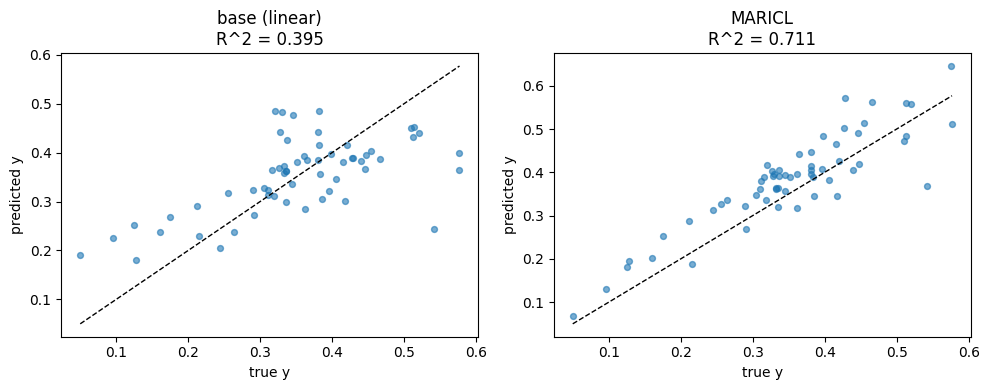

In [59]:
# evaluate on test
base_pred_te = base_reg.predict(X_te)
maricl_pred_te = maricl_reg.predict(X_te)

print(f"{'model':18s}  {'MAE':>8s}  {'R^2':>8s}")
print(f"{'base (linear)':18s}  {mean_absolute_error(y_te, base_pred_te):>8.4f}  {r2_score(y_te, base_pred_te):>8.4f}")
print(f"{'MARICL':18s}  {mean_absolute_error(y_te, maricl_pred_te):>8.4f}  {r2_score(y_te, maricl_pred_te):>8.4f}")

# Visualise predicted vs true
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, pred, name in zip(axes, [base_pred_te, maricl_pred_te], ["base (linear)", "MARICL"]):
    ax.scatter(y_te, pred, alpha=0.6, s=18)
    lo, hi = y_te.min(), y_te.max()
    ax.plot([lo, hi], [lo, hi], "k--", lw=1)
    ax.set_xlabel("true y"); ax.set_ylabel("predicted y")
    ax.set_title(f"{name}\nR^2 = {r2_score(y_te, pred):.3f}")
plt.tight_layout(); plt.show()


### Regression — extra diagnostics

The cells below **only visualize and summarize** ordinary model outputs (`predict`) and sklearn metrics on data already computed above—no MARICL private methods or internal bookkeeping.


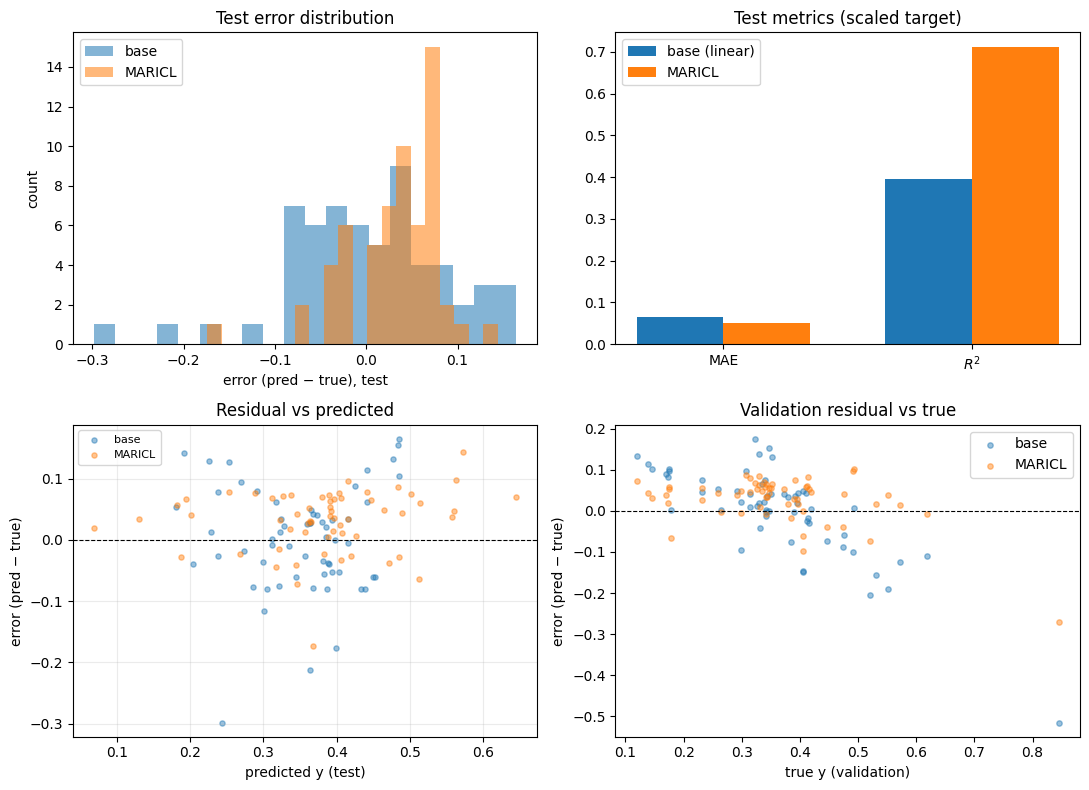

Test summary: ΔMAE (base − MARICL): +0.0150  |  ΔR² (MARICL − base): +0.3165


In [60]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
err_base = base_pred_te - y_te
err_m = maricl_pred_te - y_te
axes[0, 0].hist(err_base, bins=20, alpha=0.55, label="base", color="C0")
axes[0, 0].hist(err_m, bins=20, alpha=0.55, label="MARICL", color="C1")
axes[0, 0].set_xlabel("error (pred − true), test")
axes[0, 0].set_ylabel("count")
axes[0, 0].legend()
axes[0, 0].set_title("Test error distribution")

m_names = ["MAE", r"$R^2$"]
bv = [mean_absolute_error(y_te, base_pred_te), r2_score(y_te, base_pred_te)]
mv = [mean_absolute_error(y_te, maricl_pred_te), r2_score(y_te, maricl_pred_te)]
xm = np.arange(len(m_names))
ww = 0.35
axes[0, 1].bar(xm - ww / 2, bv, ww, label="base (linear)")
axes[0, 1].bar(xm + ww / 2, mv, ww, label="MARICL")
axes[0, 1].set_xticks(xm, m_names)
axes[0, 1].legend()
axes[0, 1].set_title("Test metrics (scaled target)")

axes[1, 0].scatter(base_pred_te, err_base, alpha=0.45, s=14, label="base", color="C0")
axes[1, 0].scatter(maricl_pred_te, err_m, alpha=0.45, s=14, label="MARICL", color="C1")
axes[1, 0].axhline(0, color="k", ls="--", lw=0.8)
axes[1, 0].set_xlabel("predicted y (test)")
axes[1, 0].set_ylabel("error (pred − true)")
axes[1, 0].set_title("Residual vs predicted")
axes[1, 0].legend(fontsize=8)
axes[1, 0].grid(alpha=0.25)

try:
    p_va_b = base_reg.predict(X_va)
    p_va_m = maricl_reg.predict(X_va)
    axes[1, 1].scatter(y_va, p_va_b - y_va, alpha=0.45, s=15, label="base", color="C0")
    axes[1, 1].scatter(y_va, p_va_m - y_va, alpha=0.45, s=15, label="MARICL", color="C1")
    axes[1, 1].axhline(0, color="k", ls="--", lw=0.8)
except NameError:
    axes[1, 1].text(
        0.5,
        0.5,
        "Validation tensors not in scope.",
        ha="center",
        va="center",
        transform=axes[1, 1].transAxes,
    )
    axes[1, 1].set_axis_off()
else:
    axes[1, 1].set_xlabel("true y (validation)")
    axes[1, 1].set_ylabel("error (pred − true)")
    axes[1, 1].set_title("Validation residual vs true")
    axes[1, 1].legend()

plt.tight_layout()
plt.show()

dmae = mean_absolute_error(y_te, base_pred_te) - mean_absolute_error(y_te, maricl_pred_te)
dr2 = r2_score(y_te, maricl_pred_te) - r2_score(y_te, base_pred_te)
print(
    "Test summary: ΔMAE (base − MARICL): "
    f"{dmae:+.4f}  |  ΔR² (MARICL − base): {dr2:+.4f}"
)


## 6. Experiment 2 — synthetic classification

Three-class problem on 4 features. The decision boundary is a nonlinear
combination of features that a *logistic* base model can only partially recover:

* class 0:  $x_1 x_2 < -0.5$
* class 2:  $x_1 x_2 >  0.5$
* class 1:  otherwise  (with a small extra dependence on $x_3^2$)


In [61]:
def make_classification_data(n=500, seed=0):
    rng = np.random.default_rng(seed)
    X = rng.standard_normal((n, 4))
    x1, x2, x3 = X[:, 0], X[:, 1], X[:, 2]
    # x3 coefficient raised 0.3→0.5 so the quadratic term creates
    # more distinct failure cases the encoder can discover
    inter = x1 * x2 + 0.5 * (x3**2 - 1.0)
    y = np.full(n, 1, dtype=int)
    y[inter < -0.5] = 0
    y[inter >  0.5] = 2
    # 2% label noise (down from 5%): cleaner residual signal for the encoder
    flip = rng.random(n) < 0.02
    y[flip] = rng.integers(0, 3, size=flip.sum())
    return X, y

Xc, yc = make_classification_data(n=500, seed=0)
print("class counts:", np.bincount(yc))

N = len(Xc)
idx = np.random.RandomState(2).permutation(N)
n_tr, n_va = int(0.6 * N), int(0.2 * N)
tr_i, va_i, te_i = idx[:n_tr], idx[n_tr:n_tr+n_va], idx[n_tr+n_va:]
Xc_tr, Xc_va, Xc_te = Xc[tr_i], Xc[va_i], Xc[te_i]
yc_tr, yc_va, yc_te = yc[tr_i], yc[va_i], yc[te_i]

base_clf = LogisticRegression(max_iter=200).fit(Xc_tr, yc_tr)
print(f"\nBase (logistic):")
print(f"  train acc = {accuracy_score(yc_tr, base_clf.predict(Xc_tr)):.3f}")
print(f"  test  acc = {accuracy_score(yc_te, base_clf.predict(Xc_te)):.3f}")
print(f"  test  macroF1 = {f1_score(yc_te, base_clf.predict(Xc_te), average='macro'):.3f}")


class counts: [147 228 125]

Base (logistic):
  train acc = 0.483
  test  acc = 0.490
  test  macroF1 = 0.247


In [62]:
# Classification-specific feature descriptions: hint at interaction structure
# without revealing the exact formula — gives the encoder something to work with
feat_descs_clf = [
    "x1: continuous standardised input; may interact multiplicatively with other features",
    "x2: continuous standardised input; may interact multiplicatively with other features",
    "x3: continuous standardised input; may have a nonlinear (quadratic) effect on class boundaries",
    "x4: continuous standardised input; independent of the class label",
]

# Domain context: describes the failure mode clearly without giving away the formula,
# but tells the decoder what structure the per-class correction should take
domain_clf = (
    "3-class synthetic benchmark. Classes are separated by a nonlinear boundary "
    "involving interactions between x1, x2, and a quadratic effect of x3. "
    "A logistic base model captures only marginal linear effects and systematically "
    "fails when x1 and x2 have the same sign (large positive x1*x2) or opposite signs "
    "(large negative x1*x2). "
    "The target correction is a Python list [delta_0, delta_1, delta_2] where each "
    "delta_c is an arithmetic expression in x1, x2, x3, x4 that scores class c higher "
    "when it is the true class."
)

maricl_clf = MARICL(
    task="classification",
    K=3,
    kappa=0.4,      # was 0.3 — more high-residual examples in encoder context
    T=8,
    tau_fail=0.35,  # was 0.5 — expose borderline cases (P(true)∈[0.35,0.5]) to critique
    beta=0.3,       # was 0.5 — give corrections more weight over the weak logistic base
    verbose=True,
)
maricl_clf.fit(
    Xc_tr, yc_tr,
    base_model=base_clf,
    feature_names=feat_names,
    feature_descs=feat_descs_clf,   # classification-specific descriptions
    domain_context=domain_clf,
    n_classes=3,
)


  high-residual pool: 120 / 300 examples (|r| range 0.677..0.871)
  [correction 0] encoder variant = error_patterns
    hypothesis: The base model is missing a nonlinear decision rule in which class_2 is boosted by the x1×x2 interaction together with a quadratic effect of x3, so large-magnitude pairwise dependence overrides the linear marginals.
    form guess: delta_2 ≈ a*(x1*x2) + b*(x3**2) with a thresholded/saturating interaction term (e.g. +softplus(k*x1*x2) or +|x1*x2|) and smaller opposing adjustments for delta_0, delta_1 || delta_2 = a*abs(x1*x2) + b*(x3**2) + c, with delta_0 and delta_1 decreasing accordingly (e.g. subtracting the same nonlinear score from class_1); x4 is ignored || delta_0 ~ -a*(x1*x2) - b*(x3^2); delta_1 ~ 0; delta_2 ~ +a*(x1*x2) + b*(x3^2) (optionally centered with a threshold on x3^2) || class-wise corrections of the form delta_0 = a0*(-x1*x2) - b0*(x3^2), delta_1 = 0, delta_2 = a2*(x1*x2) + b2*(x3^2), possibly using |x1*x2| or a threshold on x1*x2 to sepa

In [63]:
maricl_clf.show_corrections()



--- Correction 0  (p_k = 0.695, best_t = 5) ---
T_k: The residuals still point to a sign-sensitive interaction: negative x1*x2 cases need extra support for class_0, while positive x1*x2 cases with larger x3^2 need a sharper boost for class_2. I’m replacing the overly saturated, sign-agnostic interaction with clipped signed gates and giving class_2 a direct quadratic x3 contribution, while keeping class_1 suppressed in high-interaction regions.
f_k: [0.55*maximum(-clip(x1*x2, -6, 6), 0) + 0.12*maximum(-clip(x1*x2, -6, 6), 0)*clip(x3*x3, 0, 25) - 0.08*clip(x3*x3, 0, 25), -0.55*abs(clip(x1*x2, -6, 6)) - 0.15*clip(x3*x3, 0, 25) + 0.1, 0.95*maximum(clip(x1*x2, -6, 6), 0) + 0.22*clip(x3*x3, 0, 25) + 0.14*maximum(clip(x1*x2, -6, 6), 0)*clip(x3*x3, 0, 25)]

--- Correction 1  (p_k = 0.755, best_t = 8) ---
T_k: The correction now uses x1*x2 as the main separator, but lets x3^2 modulate that interaction instead of acting as an unrelated boost. This should favor class_2 when x1 and x2 align and x

In [64]:
base_pred_clf = base_clf.predict(Xc_te)
base_proba_clf = base_clf.predict_proba(Xc_te)
maricl_proba_clf = maricl_clf.predict(Xc_te)
maricl_pred_clf = maricl_proba_clf.argmax(axis=1)

print(f"{'model':18s}  {'acc':>8s}  {'macroF1':>8s}  {'logloss':>8s}")
print(f"{'base (logistic)':18s}  "
      f"{accuracy_score(yc_te, base_pred_clf):>8.3f}  "
      f"{f1_score(yc_te, base_pred_clf, average='macro'):>8.3f}  "
      f"{log_loss(yc_te, base_proba_clf, labels=[0,1,2]):>8.3f}")
print(f"{'MARICL':18s}  "
      f"{accuracy_score(yc_te, maricl_pred_clf):>8.3f}  "
      f"{f1_score(yc_te, maricl_pred_clf, average='macro'):>8.3f}  "
      f"{log_loss(yc_te, maricl_proba_clf, labels=[0,1,2]):>8.3f}")


model                    acc   macroF1   logloss
base (logistic)        0.490     0.247     1.035
MARICL                 0.660     0.632     0.872


### Classification — extra diagnostics

Confusion matrices and metric bars use only `yc_te` and the same prediction tensors as the preceding cell (`base_*` / `maricl_*` probabilities and labels)—sklearn summaries only.


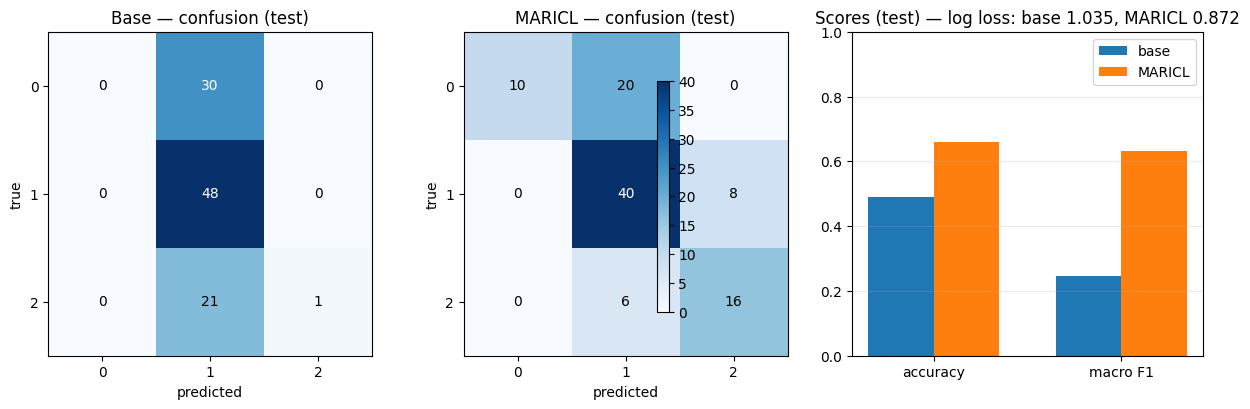

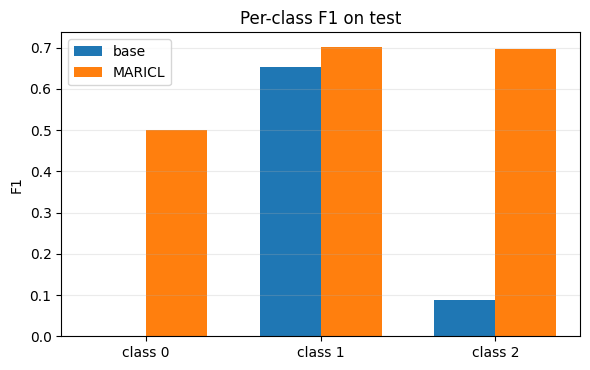

Per-class F1 [0, 1, 2]
  base:   [np.float64(0.0), np.float64(0.653), np.float64(0.087)]
  MARICL: [np.float64(0.5), np.float64(0.702), np.float64(0.696)]


In [65]:
from sklearn.metrics import confusion_matrix

lbl = [0, 1, 2]
Cm_b = confusion_matrix(yc_te, base_pred_clf, labels=lbl)
Cm_m = confusion_matrix(yc_te, maricl_pred_clf, labels=lbl)
ll_b = log_loss(yc_te, base_proba_clf, labels=lbl)
ll_m = log_loss(yc_te, maricl_proba_clf, labels=lbl)
acc_b = accuracy_score(yc_te, base_pred_clf)
acc_m = accuracy_score(yc_te, maricl_pred_clf)
f1_ma_b = f1_score(yc_te, base_pred_clf, average="macro")
f1_ma_m = f1_score(yc_te, maricl_pred_clf, average="macro")
f1_per_b = f1_score(yc_te, base_pred_clf, average=None, labels=lbl)
f1_per_m = f1_score(yc_te, maricl_pred_clf, average=None, labels=lbl)

fig, axes = plt.subplots(1, 3, figsize=(12.5, 4))

def plot_cm(ax, C, title):
    im = ax.imshow(C, cmap="Blues")
    ax.set_xticks(range(3)); ax.set_yticks(range(3))
    ax.set_xlabel("predicted"); ax.set_ylabel("true")
    ax.set_title(title)
    vmax = C.max() if C.max() > 0 else 1
    for (i, j), v in np.ndenumerate(C):
        ax.text(
            j,
            i,
            int(v),
            ha="center",
            va="center",
            color="white" if v > vmax * 0.55 else "black",
        )
    return im

plot_cm(axes[0], Cm_b, "Base — confusion (test)")
im_m = plot_cm(axes[1], Cm_m, "MARICL — confusion (test)")
plt.colorbar(im_m, ax=[axes[0], axes[1]], shrink=0.75)

xbar = np.arange(2); w = 0.35
axes[2].bar(xbar - w / 2, [acc_b, f1_ma_b], w, label="base", color="C0")
axes[2].bar(xbar + w / 2, [acc_m, f1_ma_m], w, label="MARICL", color="C1")
axes[2].set_xticks(xbar, ["accuracy", "macro F1"])
axes[2].set_ylim(0, 1)
axes[2].legend()
axes[2].set_title(f"Scores (test) — log loss: base {ll_b:.3f}, MARICL {ll_m:.3f}")
axes[2].grid(alpha=0.25, axis="y")

plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 3.8))
xk = np.arange(3); w2 = 0.35
plt.bar(xk - w2 / 2, f1_per_b, w2, label="base", color="C0")
plt.bar(xk + w2 / 2, f1_per_m, w2, label="MARICL", color="C1")
plt.xticks(xk, [f"class {c}" for c in lbl])
plt.ylabel("F1")
plt.title("Per-class F1 on test")
plt.legend()
plt.grid(alpha=0.25, axis="y")
plt.tight_layout()
plt.show()

print("Per-class F1 [0, 1, 2]")
print(f"  base:   {[round(x, 3) for x in f1_per_b]}")
print(f"  MARICL: {[round(x, 3) for x in f1_per_m]}")


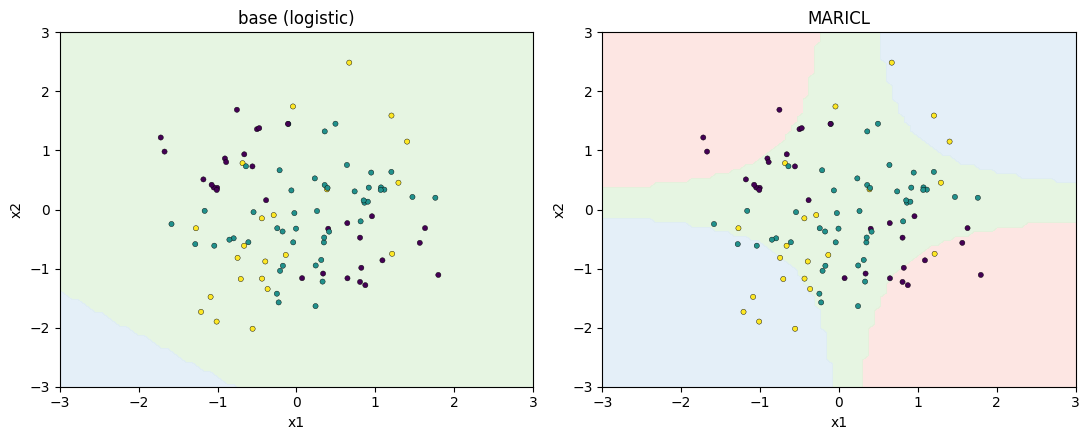

In [66]:
# decision boundary slice: hold x3=x4=0, scan x1 vs x2
xx, yy = np.meshgrid(np.linspace(-3, 3, 80), np.linspace(-3, 3, 80))
grid = np.column_stack([xx.ravel(), yy.ravel(),
                        np.zeros(xx.size), np.zeros(xx.size)])

base_grid = base_clf.predict(grid).reshape(xx.shape)
maricl_grid = maricl_clf.predict_label(grid).reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, Z, name in zip(axes, [base_grid, maricl_grid], ["base (logistic)", "MARICL"]):
    ax.contourf(xx, yy, Z, levels=[-0.5, 0.5, 1.5, 2.5],
                colors=["#fde0dd", "#e0f3db", "#deebf7"], alpha=0.8)
    ax.scatter(Xc_te[:, 0], Xc_te[:, 1], c=yc_te,
               cmap="viridis", s=14, edgecolor="k", linewidth=0.3)
    ax.set_xlabel("x1"); ax.set_ylabel("x2")
    ax.set_title(name)
plt.tight_layout(); plt.show()
